In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


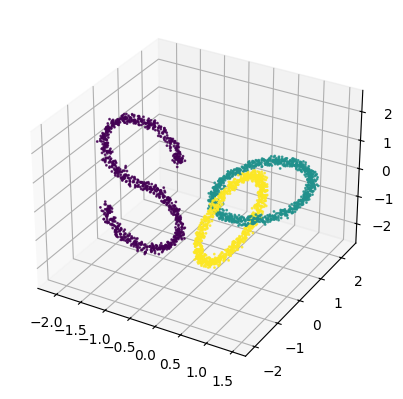

In [58]:
import numpy as np
import os
import torch

from shade import SHADE
from clustpy.utils import plot_3d_data, plot_2d_data, plot_with_transformation
from clustpy.deep import (
    DEC,
    IDEC,
    DCN,
    DipEncoder,
    DipDECK,
    DDC,
    encode_batchwise,
    get_dataloader,
    detect_device,
    get_trained_network,
)
from clustpy.deep._utils import set_torch_seed
from clustpy.deep.neural_networks import FeedforwardAutoencoder
from clustpy.metrics import unsupervised_clustering_accuracy as acc
from sklearn.metrics import normalized_mutual_info_score as nmi, adjusted_rand_score as ari
from sklearn.utils import check_random_state
from sklearn.manifold import TSNE

random_state = check_random_state(7)
random_state = set_torch_seed(random_state)

device = detect_device("cuda:0")
os.environ["CLUSTPY_DEVICE"] = "cuda:0"


from experiments.datasets.syn_data import create_multiple_shapes

DATASET = "motivation"
X, labels = create_multiple_shapes()

def standardize(data, axis=None):
    mean = np.mean(data, axis=axis)
    std = np.std(data, axis=axis)
    return (data - mean) / std

X = standardize(X, axis=0)

plot_3d_data(X, labels, show_legend=False, scattersize=1)

Neural network is not fitted yet, will be pretrained.


AE training: 100%|██████████████████████████████████████████████| 100/100 [00:09<00:00, 10.00it/s, Training Loss=0.0599]


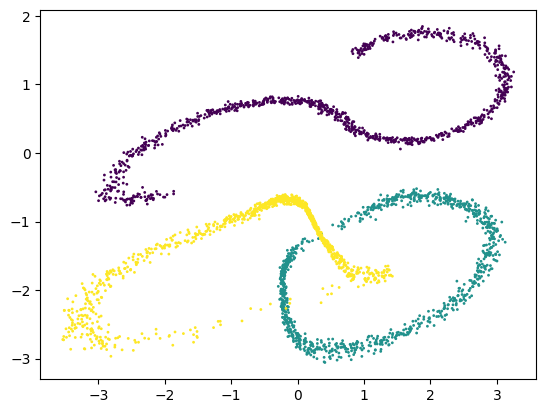

In [ ]:
pretrain_ae = False

trainloader = get_dataloader(X, 256, shuffle=True, drop_last=False)
dataloader = get_dataloader(X, 256, shuffle=False, drop_last=False)

if pretrain_ae:
    ae = get_trained_network(
        trainloader=trainloader,
        data=X,
        n_epochs=100,
        optimizer_params={"lr": 1e-3},
        optimizer_class=torch.optim.Adam,
        device=device,
        ssl_loss_fn=torch.nn.MSELoss(),
        embedding_size=2,
        neural_network_class=FeedforwardAutoencoder,
        neural_network_params={"layers": [3, 500, 500, 2000, 2]},
    )
    ae.save_parameters(
        "experiments/motivation/pretrained_ae.mdl"
    )
else:
    ae = FeedforwardAutoencoder([3, 500, 500, 2000, 2])
    ae.load_parameters(
        "experiments/motivation/pretrained_ae.mdl"
    )

embedded = encode_batchwise(dataloader, ae)
plot_2d_data(embedded, labels, show_legend=False, scattersize=1)

n_clusters: 10
nmi 0.6495263060528667
acc 0.476
ari 0.4182292643130075


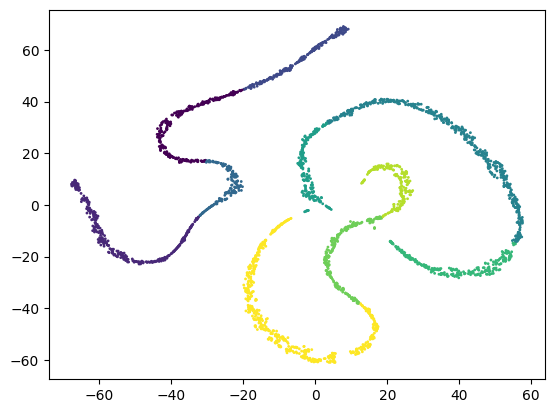

In [33]:
clusterer = DDC(embedding_size=2, neural_network=ae, random_state=random_state).fit(X)
# clusterer = DipDECK(n_clusters_init=3, embedding_size=2, neural_network=ae, random_state=random_state).fit(X)
embedded = encode_batchwise(dataloader, clusterer.neural_network)
if hasattr(clusterer, "tsne_"):
    embedded = clusterer.tsne_.fit_transform(embedded)
# embedded = TSNE(n_components=2).fit_transform(embedded)
if hasattr(clusterer, "n_clusters_"):
    print("n_clusters:", clusterer.n_clusters_)
print("nmi", nmi(labels, clusterer.labels_))
print("acc", acc(labels, clusterer.labels_))
print("ari", ari(labels, clusterer.labels_))
plot_2d_data(embedded, clusterer.labels_, show_legend=False, scattersize=1)

In [54]:
def autoenc_emb(X, emb_size=2):
    random_state = check_random_state(7)
    random_state = set_torch_seed(random_state)
    ffa = FeedforwardAutoencoder(layers=[X.shape[1], 512, 256, 128, emb_size])
    x_tensor = torch.tensor(X, dtype=torch.float)
    ffa.fit(data=x_tensor, batch_size=500, n_epochs=100, optimizer_params={})
    emb = ffa.encode(x_tensor).detach().numpy()
    return emb

In [55]:
from experiments.motivation.dcsi import dcsiscore

def clustering(cluster_alg, X, L, args=[], kwargs={}):
    random_state = check_random_state(7)
    random_state = set_torch_seed(random_state)
    clusterer = cluster_alg(*args, **kwargs)
    clusterer.fit(X)
    dataloader = get_dataloader(X, 256, shuffle=False, drop_last=False)
    embedded = encode_batchwise(dataloader, clusterer.neural_network)
    if cluster_alg.__name__ == "DDC":
        embedded = TSNE(n_components=clusterer.embedding_size).fit_transform(embedded)
    print("nmi", nmi(L, clusterer.labels_))
    print("acc", acc(L, clusterer.labels_))
    print("ari", ari(L, clusterer.labels_))
    # plot_2d_data(embedded, L, show_legend=False, scattersize=1)
    return embedded

In [56]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

from sklearn.cluster import OPTICS

def reachability_plot(X):
    random_state = check_random_state(7)
    random_state = set_torch_seed(random_state)
    clust = OPTICS(min_samples=50, xi=0.05, min_cluster_size=0.05)
    clust.fit(X)

    space = np.arange(len(X))
    reachability = clust.reachability_[clust.ordering_]
    labels = clust.labels_[clust.ordering_]
    labels = labels[clust.ordering_]
    clusters = set(labels)
    cmap = plt.colormaps["viridis"]
    colors = cmap(np.linspace(0, 1, len(clusters)))

    fig = plt.figure(figsize=(10, 3))
    G = gridspec.GridSpec(1, 3)
    ax1 = plt.subplot(G[0, :])
    # ax3 = plt.subplot(G[1, 1])
    # ax4 = plt.subplot(G[1, 2])

    # Reachability plot
    ax1.plot(space, reachability, marker='', c='black', alpha=0.7, linestyle="-", linewidth=0.8)
    for cluster_id, color in zip(clusters, colors):
        Xk = space[labels == cluster_id]
        Rk = reachability[labels == cluster_id]
        ax1.plot(Xk, Rk, marker='.', markersize=12, c=color, alpha=0.1, linestyle='', linewidth=2.0)

    # ax1.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
    # ax1.plot(space, np.full_like(space, 2.0, dtype=float), "k-", alpha=0.5)
    # ax1.plot(space, np.full_like(space, 0.5, dtype=float), "k-.", alpha=0.5)
    # ax1.set_ylabel("Reachability (epsilon distance)")
    # ax1.set_title("Reachability Plot")

    # ax1.set_xticks([])
    ax1.tick_params(axis="x", labelsize=18)
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(4))

    # ax1.set_yticks([])
    ax1.tick_params(axis="y", labelsize=20)
    v_min = np.nanmin(reachability[reachability != -np.inf])
    v_max = np.nanmax(reachability[reachability != np.inf])
    ax1.yaxis.set_major_locator(ticker.FixedLocator(np.linspace(v_min, v_max, 4)))
    ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.2f}"))
    return fig

orig
dcsiscore 0.9808641378672669


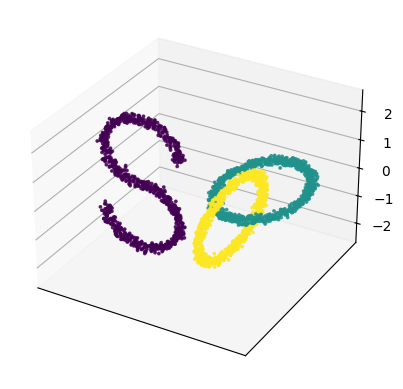

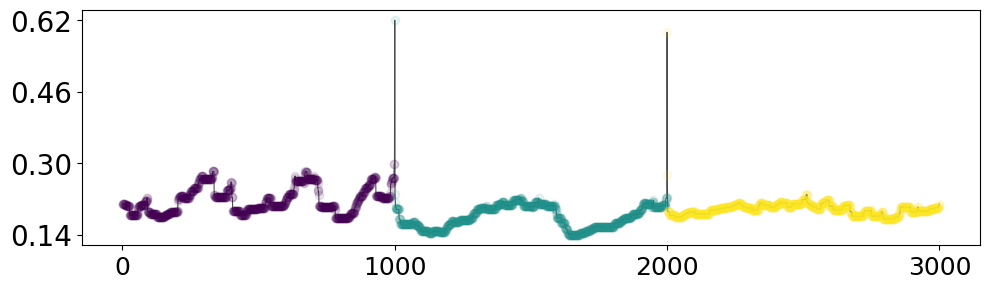

AE


AE training: 100%|██████████████████████████████████████████████| 100/100 [00:04<00:00, 22.65it/s, Training Loss=0.0159]


dcsiscore 0.825200956498964


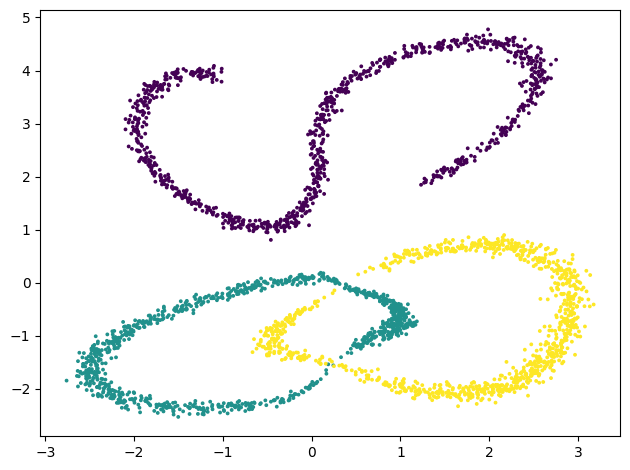

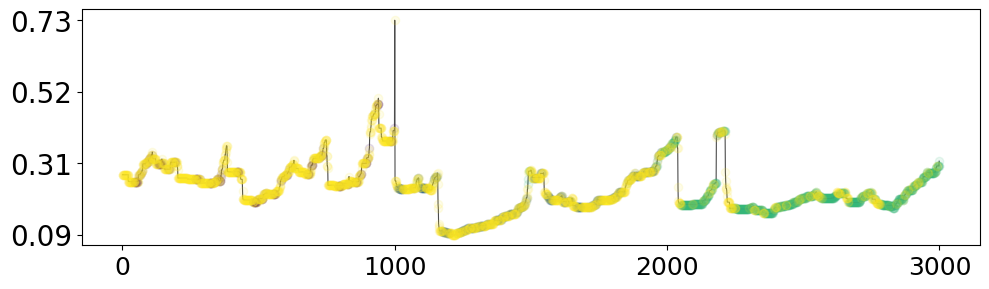

SHADE
Build DCTree of the complete dataset
Neural network is not fitted yet, will be pretrained.


AE training: 0it [00:00, ?it/s]


Start training with clustering loss.
Compute dc_distance matrix.
Epoch: 100%|██████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.86it/s]
nmi 1.0
acc 1.0
ari 1.0
dcsiscore 0.9971784200408156


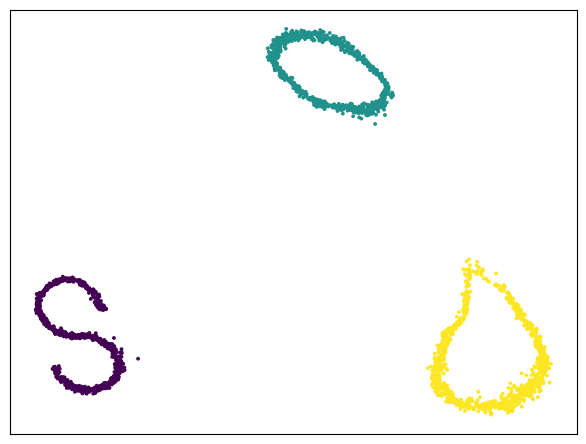

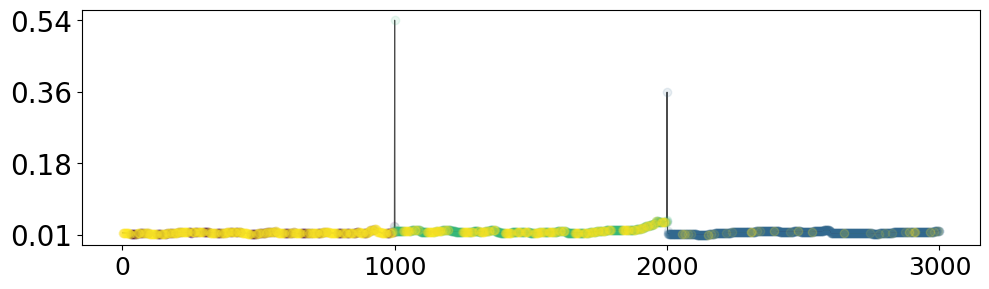

DEC
Neural network is not fitted yet, will be pretrained.


DEC training: 100%|████████████████████████████████████████████████████████| 150/150 [00:14<00:00, 10.16it/s, Loss=1.41]


nmi 0.30852951811215906
acc 0.5763333333333334
ari 0.2788065155868909
dcsiscore 2.669600363813601e-10


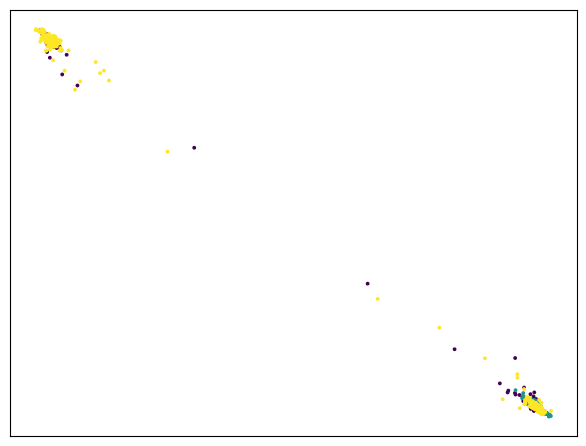

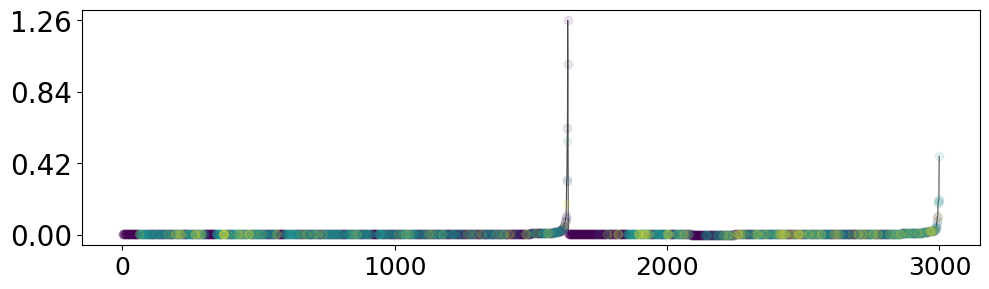

IDEC
Neural network is not fitted yet, will be pretrained.


DEC training: 100%|███████████████████████████████████████████████████████| 150/150 [00:21<00:00,  7.12it/s, Loss=0.201]


nmi 0.2843486001986476
acc 0.5616666666666666
ari 0.2494006012856626
dcsiscore 0.002273777747416013


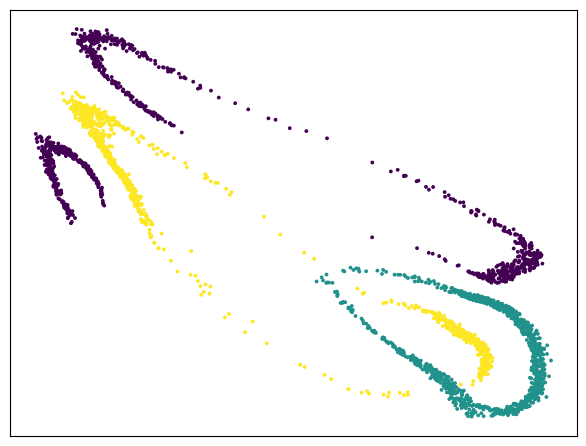

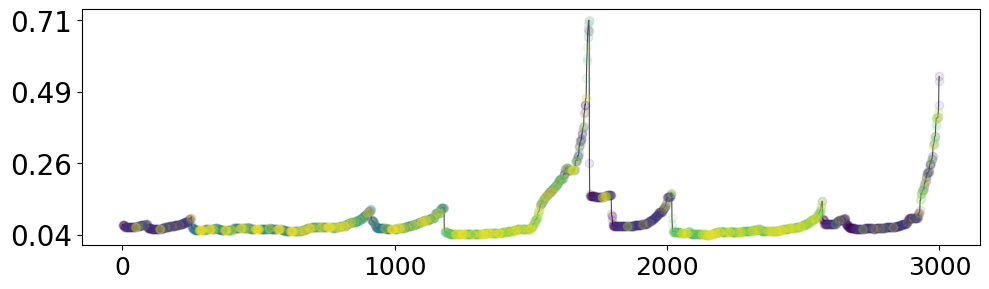

DCN
Neural network is not fitted yet, will be pretrained.


DCN training: 100%|████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.84it/s, Loss=0.0434]


nmi 0.2625996258639848
acc 0.562
ari 0.21980762119692174
dcsiscore 0.050227109319592164


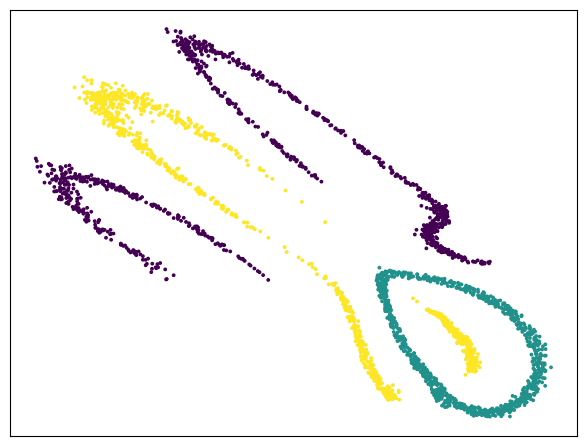

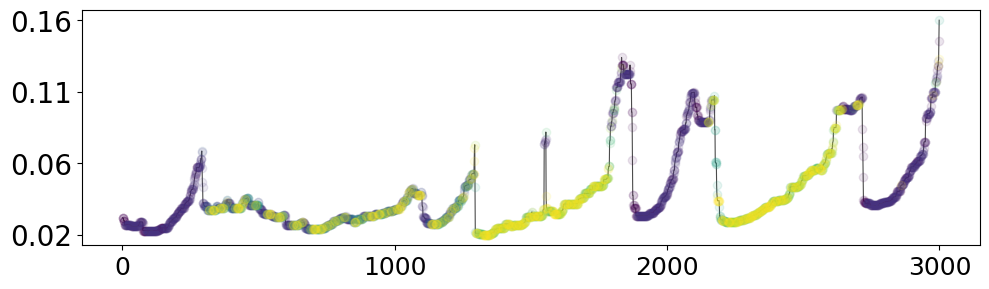

DipEncoder
Neural network is not fitted yet, will be pretrained.


AE training: 100%|███████████████████████████████████████████████| 100/100 [00:41<00:00,  2.41it/s, Training Loss=0.293]


Setting ssl_loss_weight automatically; set to tensor(0.2418, device='cuda:0')


DipEncoder training:  99%|██████████████████████████████████████████████▌| 100/101 [00:52<00:00,  1.91it/s, Loss=-0.953]


nmi 0.33821290628413175
acc 0.5296666666666666
ari 0.18286949133089545
dcsiscore 0.010836357623981042


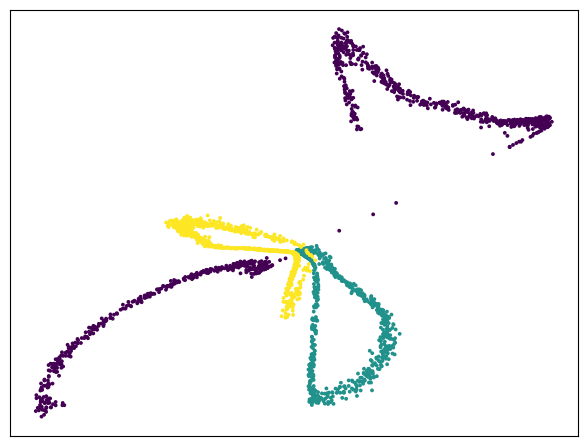

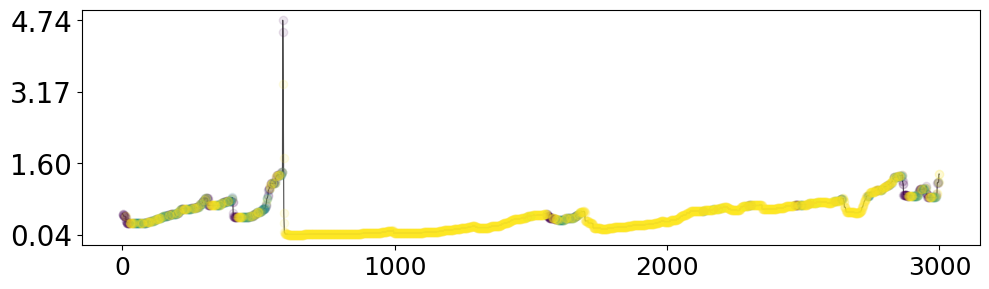

DipDECK
Neural network is not fitted yet, will be pretrained.


DipDECK training: 100%|████████████████████████████| 50/50 [00:09<00:00,  5.45it/s, n_clusters=2, Loss=0.237, Max dip=0]


nmi 0.20199299547516938
acc 0.5166666666666667
ari 0.142830606331301
dcsiscore 0.002055170265369964


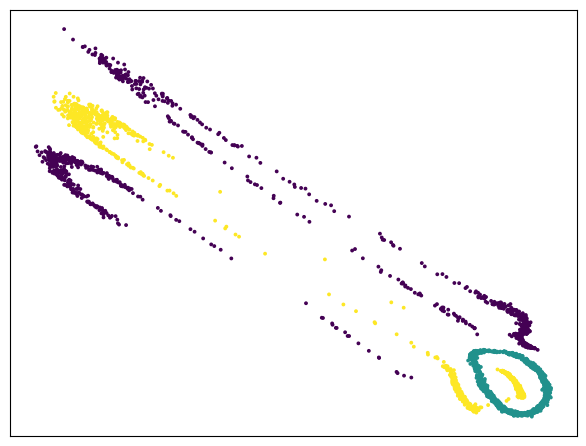

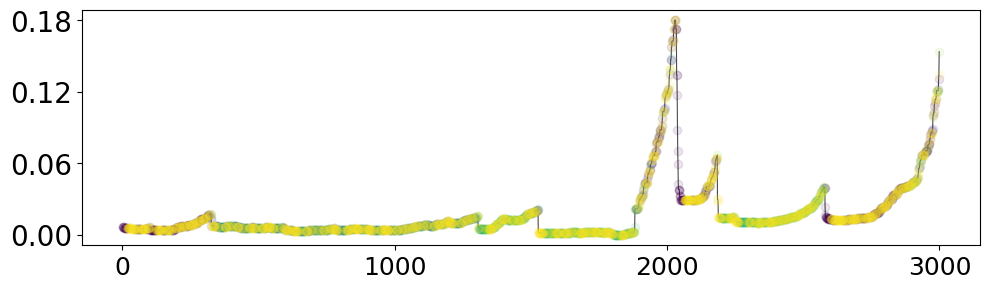

DDC
Neural network is not fitted yet, will be pretrained.


AE training: 100%|██████████████████████████████████████████████| 100/100 [00:09<00:00, 10.38it/s, Training Loss=0.0401]


nmi 0.5577462463464886
acc 0.36033333333333334
ari 0.29178297655758056
dcsiscore 0.07671576155001039


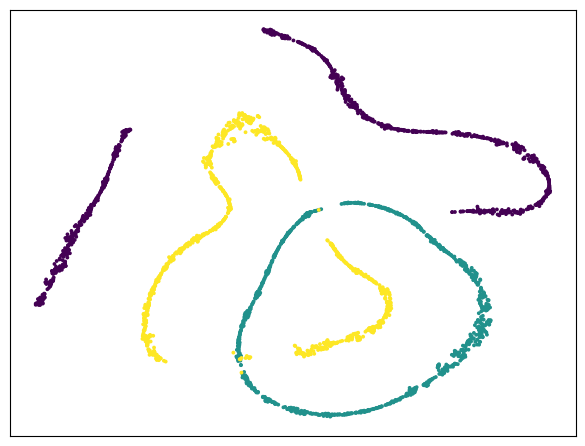

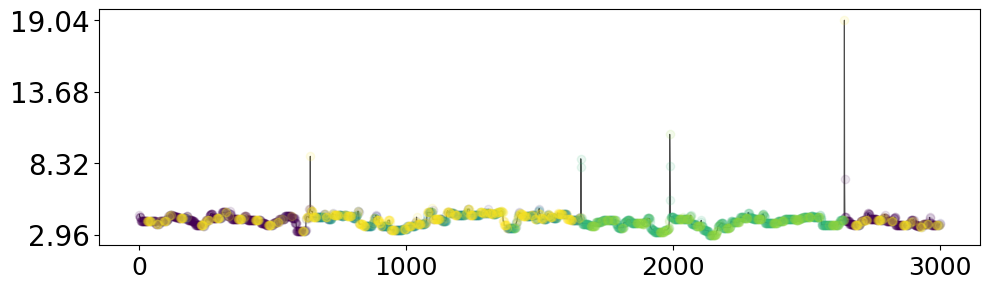

In [59]:
# ae = FeedforwardAutoencoder([3, 500, 500, 2000, 2])
# ae.load_parameters("pretrained_ae.mdl")

recalc = True
emb_size = 2
n_clusters = len(set(labels[labels>0]))

shade_params = {"embedding_size": emb_size, "random_state": random_state}
ddc_params = {"embedding_size": emb_size, "random_state": random_state}
alg_k_params = {
    "n_clusters": n_clusters,
    "embedding_size": emb_size,
    "random_state": random_state,
}
alg_dipk_params = {
    "n_clusters_init": n_clusters,
    "embedding_size": emb_size,
    "random_state": random_state,
}

algs = [
    (SHADE, shade_params),
    (DEC, alg_k_params),
    (IDEC, alg_k_params),
    (DCN, alg_k_params),
    (DipEncoder, alg_k_params),
    (DipDECK, alg_dipk_params),
    (DDC, ddc_params),
]

print("orig")
print("dcsiscore", dcsiscore(X, labels))
random_state = check_random_state(7)
random_state = set_torch_seed(random_state)
plot_3d_data(X, labels, scattersize=3, show_legend=False, show_plot=False)

# fig.savefig(f"embedding/3D")
plt.show()
fig = reachability_plot(X)
fig.tight_layout()
# fig.savefig(f"reachability/3D")
plt.show(fig)


print("AE")
random_state = check_random_state(7)
random_state = set_torch_seed(random_state)
emb = autoenc_emb(X)
print("dcsiscore", dcsiscore(emb, labels))
plot_with_transformation(emb, labels, scattersize=3, show_legend=False, show_plot=False)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
# plt.savefig(f"embedding/ae")
plt.show()
fig = reachability_plot(emb)
fig.tight_layout()
# fig.savefig(f"reachability/AE")
plt.show(fig)


for cluster_alg, kwargs in algs:
    print(cluster_alg.__name__)
    emb = clustering(cluster_alg, X, labels, [], kwargs)
    print("dcsiscore", dcsiscore(emb, labels))
    plot_with_transformation(
        emb,
        labels,
        scattersize=3,
        show_legend=False,
        show_plot=False
    )
    plt.tight_layout()
    plt.xticks([])
    plt.yticks([])
    # plt.savefig(f"embedding/" + cluster_alg.__name__)
    plt.show()
    fig = reachability_plot(emb)
    fig.tight_layout()
    # fig.savefig(f"reachability/" + cluster_alg.__name__)
    plt.show(fig)

SHADE


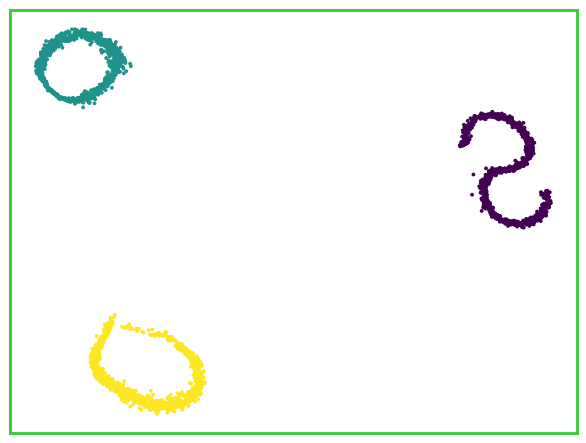

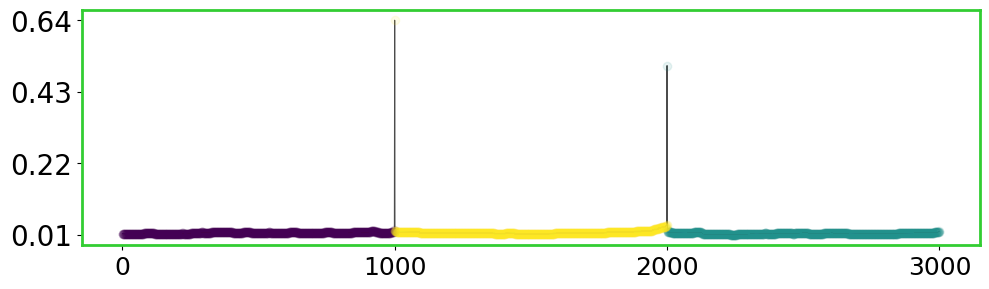

In [ ]:
plt.rc("axes", edgecolor="limegreen", linewidth=2)

print("SHADE")
emb = load_or_calc("SHADE", clustering, args=[cluster_alg, X, labels, [], kwargs], recalc=False)
plot_with_transformation(
    emb,
    labels,
    scattersize=3,
    show_legend=False,
    show_plot=False
)

plt.tight_layout()
plt.xticks([])
plt.yticks([])
# plt.savefig(f"embedding/" + "SHADE")
plt.show()
fig = reachability_plot(emb)
fig.tight_layout()
# fig.savefig(f"reachability/" + "SHADE")
plt.show(fig)

plt.rcdefaults()